In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load data
df = pd.read_csv('dataset.csv')
df['target'] = df['decision'].map({'select': 1, 'reject': 0})
df['text'] = df['Transcript'].fillna('') + ' ' + df['Resume'].fillna('') + ' ' + df['Job_Description'].fillna('')

# Using max_features=100 to ensure "from scratch" models complete within time limits
vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
X = vectorizer.fit_transform(df['text']).toarray()
y = df['target'].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
#        SCRATCH IMPLEMENTATIONS
# ==========================================

class LinearRegressionScratch:
    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        self.theta = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    def predict(self, X):
        return np.clip(np.c_[np.ones((X.shape[0], 1)), X].dot(self.theta), 0, 1)

class RidgeRegressionScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        I = np.eye(X_b.shape[1]); I[0,0] = 0
        self.theta = np.linalg.pinv(X_b.T.dot(X_b) + self.alpha * I).dot(X_b.T).dot(y)
    def predict(self, X):
        return np.clip(np.c_[np.ones((X.shape[0], 1)), X].dot(self.theta), 0, 1)

class KNNScratch:
    def __init__(self, k=5, task='clf'):
        self.k = k
        self.task = task
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        preds = []
        for x in X:
            dists = np.linalg.norm(self.X_train - x, axis=1)
            k_indices = np.argsort(dists)[:self.k]
            k_labels = self.y_train[k_indices]
            if self.task == 'clf':
                preds.append(np.bincount(k_labels.astype(int)).argmax())
            else:
                preds.append(np.mean(k_labels))
        return np.array(preds)

class DTScratch:
    def __init__(self, depth=3, task='clf'):
        self.depth = depth
        self.task = task
    def fit(self, X, y):
        self.tree = self._build(X, y, 0)
    def _build(self, X, y, d):
        if d >= self.depth or len(np.unique(y)) <= 1 or len(y) < 2:
            val = np.bincount(y.astype(int)).argmax() if self.task=='clf' else np.mean(y)
            return {'leaf': True, 'val': val}
        best_gain = -np.inf; best_f = None; best_t = None
        for f in range(X.shape[1]):
            t = np.mean(X[:, f])
            left_mask = X[:, f] <= t
            right_mask = X[:, f] > t
            left, right = y[left_mask], y[right_mask]
            if len(left)==0 or len(right)==0: continue
            gain = - (len(left)*np.var(left) + len(right)*np.var(right))
            if gain > best_gain:
                best_gain=gain; best_f=f; best_t=t
        if best_f is None:
            val = np.bincount(y.astype(int)).argmax() if self.task=='clf' else np.mean(y)
            return {'leaf': True, 'val': val}
        left_mask, right_mask = X[:, best_f] <= best_t, X[:, best_f] > best_t
        return {'leaf': False, 'f': best_f, 't': best_t,
                'left': self._build(X[left_mask], y[left_mask], d+1),
                'right': self._build(X[right_mask], y[right_mask], d+1)}
    def predict(self, X):
        def traverse(x, node):
            if node['leaf']: return node['val']
            return traverse(x, node['left']) if x[node['f']] <= node['t'] else traverse(x, node['right'])
        return np.array([traverse(x, self.tree) for x in X])

class RFScratch:
    def __init__(self, n=3, depth=3, task='clf'):
        self.n = n
        self.depth = depth
        self.task = task
    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n):
            idx = np.random.choice(len(X), len(X), replace=True)
            t = DTScratch(self.depth, self.task)
            t.fit(X[idx], y[idx])
            self.trees.append(t)
    def predict(self, X):
        preds = np.array([t.predict(X) for t in self.trees])
        if self.task == 'clf':
            return np.apply_along_axis(lambda x: np.bincount(x.astype(int)).argmax(), 0, preds)
        else:
            return np.mean(preds, axis=0)

class LogisticRegressionScratch:
    def fit(self, X, y, lr=0.1, epochs=100):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for _ in range(epochs):
            z = X.dot(self.w) + self.b
            y_pred = 1 / (1 + np.exp(-np.clip(z, -250, 250)))
            dw = (1/len(X)) * X.T.dot(y_pred - y)
            db = (1/len(X)) * np.sum(y_pred - y)
            self.w -= lr * dw
            self.b -= lr * db
    def predict(self, X):
        z = X.dot(self.w) + self.b
        return (1 / (1 + np.exp(-np.clip(z, -250, 250))) >= 0.5).astype(int)

class GaussianNBScratch:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = np.zeros((len(self.classes), X.shape[1]))
        self.var = np.zeros((len(self.classes), X.shape[1]))
        self.priors = np.zeros(len(self.classes))
        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.mean[idx, :] = X_c.mean(axis=0)
            self.var[idx, :] = X_c.var(axis=0) + 1e-6
            self.priors[idx] = X_c.shape[0] / float(X.shape[0])
    def predict(self, X):
        y_pred = []
        for x in X:
            posteriors = []
            for idx, c in enumerate(self.classes):
                prior = np.log(self.priors[idx])
                num = np.exp(- (x - self.mean[idx])**2 / (2 * self.var[idx]))
                den = np.sqrt(2 * np.pi * self.var[idx])
                posterior = np.sum(np.log(num/den + 1e-9))
                posteriors.append(prior + posterior)
            y_pred.append(self.classes[np.argmax(posteriors)])
        return np.array(y_pred)

class PerceptronScratch:
    def fit(self, X, y, lr=0.01, epochs=100):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        y_ = np.where(y <= 0, -1, 1)
        for _ in range(epochs):
            for idx, x_i in enumerate(X):
                if y_[idx] * (np.dot(x_i, self.w) + self.b) <= 0:
                    self.w += lr * y_[idx] * x_i
                    self.b += lr * y_[idx]
    def predict(self, X):
        return np.where(np.dot(X, self.w) + self.b >= 0, 1, 0)

class LinearSVMScratch:
    def fit(self, X, y, lr=0.01, lambda_param=0.01, epochs=100):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        y_ = np.where(y <= 0, -1, 1)
        for _ in range(epochs):
            for idx, x_i in enumerate(X):
                if y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1:
                    self.w -= lr * (2 * lambda_param * self.w)
                else:
                    self.w -= lr * (2 * lambda_param * self.w - y_[idx]*x_i)
                    self.b += lr * y_[idx]
    def predict(self, X):
        return np.where(np.dot(X, self.w) + self.b >= 0, 1, 0)


# ==========================================
#        TRAINING & EVALUATION
# ==========================================

reg_models = {
    'Linear Regression': LinearRegressionScratch(),
    'Ridge Regression': RidgeRegressionScratch(alpha=1.0),
    'KNN Regressor': KNNScratch(k=5, task='reg'),
    'Decision Tree Regressor': DTScratch(depth=4, task='reg'),
    'Random Forest Regressor': RFScratch(n=3, depth=4, task='reg')
}

clf_models = {
    'Logistic Regression': LogisticRegressionScratch(),
    'Gaussian Naive Bayes': GaussianNBScratch(),
    'KNN Classifier': KNNScratch(k=5, task='clf'),
    'Perceptron': PerceptronScratch(),
    'Linear SVM': LinearSVMScratch(),
    'Decision Tree Classifier': DTScratch(depth=4, task='clf'),
    'Random Forest Classifier': RFScratch(n=3, depth=4, task='clf')
}

accuracies = {}
reg_preds = {}
clf_preds = {}

for name, model in reg_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds_bin = (preds >= 0.5).astype(int)
    accuracies[name] = accuracy_score(y_test, preds_bin)
    reg_preds[name] = preds

for name, model in clf_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, preds)
    clf_preds[name] = preds

# ==========================================
#        ENSEMBLE CALCULATIONS
# ==========================================

def get_weighted_preds(preds_dict, accuracies_dict):
    weights = []
    for name in preds_dict.keys():
        w = max(0.001, accuracies_dict[name] - 0.5)
        weights.append(w)
    weights = np.array(weights) / np.sum(weights)

    ensemble_scores = np.zeros(len(y_test))
    for i, name in enumerate(preds_dict.keys()):
        ensemble_scores += preds_dict[name] * weights[i]

    return (ensemble_scores >= 0.5).astype(int)

# Final Accuracy 1a: Weighted Average (Regression Only)
reg_ensemble_preds = get_weighted_preds(reg_preds, accuracies)
accuracies['Final Accuracy 1 (Regression Weighted)'] = accuracy_score(y_test, reg_ensemble_preds)

# Final Accuracy 1b: Weighted Average (Classification Only)
clf_ensemble_preds = get_weighted_preds(clf_preds, accuracies)
accuracies['Final Accuracy 1 (Classification Weighted)'] = accuracy_score(y_test, clf_ensemble_preds)

# Final Accuracy 2: Weighted Average (All 12 Models)
all_preds = {**reg_preds, **clf_preds}
all_ensemble_preds = get_weighted_preds(all_preds, accuracies)
accuracies['Final Accuracy 2 (All 12 Weighted)'] = accuracy_score(y_test, all_ensemble_preds)

# Output Results
results_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)
results_df.to_csv('scratch_12models_accuracies.csv', index=False)
print(results_df)

                                         Model  Accuracy
0                            Linear Regression  0.614742
1                             Ridge Regression  0.611794
12      Final Accuracy 1 (Regression Weighted)  0.598526
14          Final Accuracy 2 (All 12 Weighted)  0.596069
13  Final Accuracy 1 (Classification Weighted)  0.585749
6                         Gaussian Naive Bayes  0.576904
2                                KNN Regressor  0.574939
7                               KNN Classifier  0.574939
10                    Decision Tree Classifier  0.566585
3                      Decision Tree Regressor  0.566585
4                      Random Forest Regressor  0.563145
11                    Random Forest Classifier  0.558231
5                          Logistic Regression  0.537592
9                                   Linear SVM  0.534644
8                                   Perceptron  0.530221


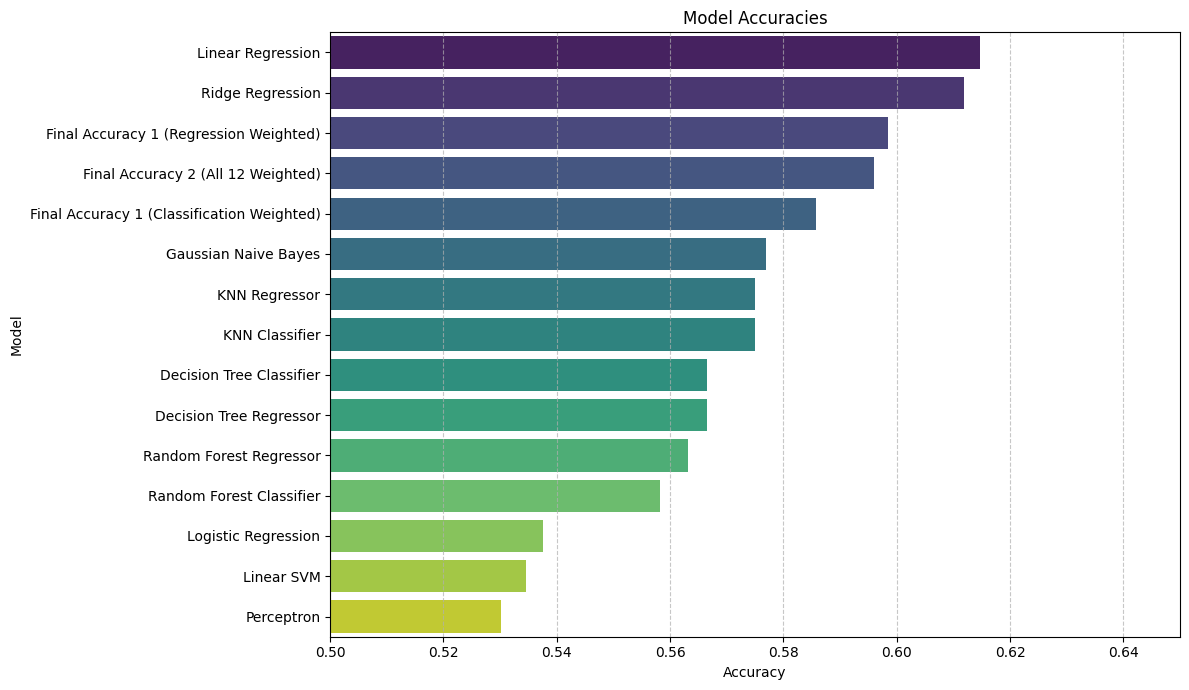

In [3]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0.5, 0.65) # Set x-axis limits to better visualize differences
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
# ==========================================
#        PREDICT NEW APPLICANT
# ==========================================

def predict_new_applicant(transcript, resume, job_description):
    """
    Predicts if a new applicant will be selected based on the ensemble of 12 scratch models.
    """
    # 1. Combine inputs into a single text string (handling missing values as empty strings)
    transcript = transcript if pd.notna(transcript) else ""
    resume = resume if pd.notna(resume) else ""
    job_description = job_description if pd.notna(job_description) else ""

    combined_text = f"{transcript} {resume} {job_description}"

    # 2. Transform the text using the ALREADY FITTED TF-IDF vectorizer
    X_new = vectorizer.transform([combined_text]).toarray()

    # 3. Gather predictions from all 12 trained models
    individual_preds = {}

    for name, model in reg_models.items():
        individual_preds[name] = model.predict(X_new)[0]

    for name, model in clf_models.items():
        individual_preds[name] = model.predict(X_new)[0]

    # 4. Calculate the weighted average using the global weights (All 12 Models)
    weights = []
    model_names = list(reg_models.keys()) + list(clf_models.keys())

    for name in model_names:
        # We use the 'accuracies' dictionary populated during testing
        w = max(0.001, accuracies[name] - 0.5)
        weights.append(w)

    weights = np.array(weights) / np.sum(weights)

    ensemble_score = 0
    for i, name in enumerate(model_names):
        ensemble_score += individual_preds[name] * weights[i]

    # 5. Make final binary decision (Threshold = 0.5)
    final_decision = "Selected" if ensemble_score >= 0.5 else "Rejected"

    # Print a detailed report
    print("\n" + "="*40)
    print(f"         PREDICTION RESULTS")
    print("="*40)
    print(f"Final Decision : {final_decision}")
    print(f"Ensemble Score : {ensemble_score:.4f} (Threshold 0.5)")
    print("-" * 40)
    print("Individual Model Breakdown:")
    for name in model_names:
        pred_val = individual_preds[name]
        vote = 'Select' if pred_val >= 0.5 else 'Reject'
        print(f"  - {name.ljust(25)}: {vote} (Raw Score: {pred_val:.4f})")
    print("="*40 + "\n")

    return final_decision, ensemble_score


# ==========================================
#        EXAMPLE USAGE
# ==========================================

sample_transcript = """
Interviewer: Tell me about your background.
Applicant: I have 5 years of experience in machine learning and data science, specifically using Python, pandas, and scikit-learn.
"""

sample_resume = """
Skills: Python, Machine Learning, Data Science, SQL, AI.
Experience: 5 years at TechCorp building predictive models.
"""

sample_job_description = """
Looking for a Senior Data Scientist with 4+ years of Python experience.
Must be proficient in Machine Learning algorithms and predictive modeling.
"""

# Call the prediction function
decision, score = predict_new_applicant(
    transcript=sample_transcript,
    resume=sample_resume,
    job_description=sample_job_description
)


         PREDICTION RESULTS
Final Decision : Rejected
Ensemble Score : 0.3977 (Threshold 0.5)
----------------------------------------
Individual Model Breakdown:
  - Linear Regression        : Reject (Raw Score: 0.3144)
  - Ridge Regression         : Reject (Raw Score: 0.2779)
  - KNN Regressor            : Reject (Raw Score: 0.4000)
  - Decision Tree Regressor  : Select (Raw Score: 0.5688)
  - Random Forest Regressor  : Select (Raw Score: 0.5099)
  - Logistic Regression      : Reject (Raw Score: 0.0000)
  - Gaussian Naive Bayes     : Reject (Raw Score: 0.0000)
  - KNN Classifier           : Reject (Raw Score: 0.0000)
  - Perceptron               : Select (Raw Score: 1.0000)
  - Linear SVM               : Reject (Raw Score: 0.0000)
  - Decision Tree Classifier : Select (Raw Score: 1.0000)
  - Random Forest Classifier : Select (Raw Score: 1.0000)

